# 08. Analyse du Dataset et Amélioration des Scores

**Objectif** : Analyser en détail le dataset pour identifier les améliorations possibles

**Pour les data scientists** : Ce notebook examine les données et propose des améliorations

In [10]:
# Importer les bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats
import re
import time

warnings.filterwarnings('ignore')

# Configuration
%matplotlib inline
try:
    plt.style.use('seaborn-v0_8')
except:
    try:
        plt.style.use('seaborn')
    except:
        plt.style.use('default')

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("📚 Bibliothèques importées avec succès !")
print("🔍 Analyse du Dataset et Amélioration des Scores")

📚 Bibliothèques importées avec succès !
🔍 Analyse du Dataset et Amélioration des Scores


In [11]:
# Charger et analyser le dataset original
print("=== CHARGEMENT DU DATASET ORIGINAL ===")

# Charger les données
df = pd.read_csv("../data/real_estate_processed.csv")
print(f"Dataset original: {df.shape}")
print(f"Colonnes: {list(df.columns)}")

# Afficher les premières lignes
print("\n📋 Aperçu des données:")
display(df.head())

# Informations générales
print(f"\n📊 INFORMATIONS GÉNÉRALES:")
print(f"   Lignes: {len(df):,}")
print(f"   Colonnes: {len(df.columns)}")
print(f"   Valeurs manquantes: {df.isnull().sum().sum()}")
print(f"   Types de données: {df.dtypes.value_counts().to_dict()}")

# Statistiques des prix
print(f"\n💰 STATISTIQUES DES PRIX:")
print(f"   Moyenne: {df['price'].mean():,.0f} DT")
print(f"   Médiane: {df['price'].median():,.0f} DT")
print(f"   Écart-type: {df['price'].std():,.0f} DT")
print(f"   Min: {df['price'].min():,.0f} DT")
print(f"   Max: {df['price'].max():,.0f} DT")
print(f"   Skewness: {stats.skew(df['price']):.4f}")
print(f"   Kurtosis: {stats.kurtosis(df['price']):.4f}")

=== CHARGEMENT DU DATASET ORIGINAL ===
Dataset original: (5653, 12)
Colonnes: ['title', 'price_text', 'price', 'category', 'city', 'location', 'type_transaction', 'rooms', 'post_time', 'post_date', 'post_month', 'post_year']

📋 Aperçu des données:


,title,price_text,price,category,city,location,type_transaction,rooms,post_time,post_date,post_month,post_year
0,À louer – Bureaux neufs S+1 et S+2 à Monastir ...,650 DT,650,0,Monastir,Monastir,0,1,2/4/26 12:37,02-04-26,2,2026
1,S+1 haut standing pour la saison universitaire,850 DT,850,0,Monastir,Monastir,0,1,8/30/25 10:49,08-30-25,8,2025
2,à vendre s+3 haut standing directement au prom...,350000 DT,350000,1,Monastir,Bekalta,1,3,7/30/25 12:45,07-30-25,7,2025
3,Appartement s+1 vue sur mer pour vacance d’été...,1540 DT,1540,2,Monastir,Bekalta,0,1,6/17/25 9:41,06-17-25,6,2025
4,Studio mignon estivale,55 DT,55,0,Monastir,Monastir,0,0,6/10/25 20:59,06-10-25,6,2025



📊 INFORMATIONS GÉNÉRALES:
   Lignes: 5,653
   Colonnes: 12
   Valeurs manquantes: 0
   Types de données: {dtype('O'): 7, dtype('int64'): 5}

💰 STATISTIQUES DES PRIX:
   Moyenne: 260,278 DT
   Médiane: 3,500 DT
   Écart-type: 3,889,321 DT
   Min: 0 DT
   Max: 210,000,000 DT
   Skewness: 47.6363
   Kurtosis: 2358.6437


In [12]:
# Analyse détaillée des colonnes
print("=== ANALYSE DÉTAILLÉE DES COLONNES ===")

# Analyse de chaque colonne
for col in df.columns:
    print(f"\n🔍 COLONNE: {col}")
    print(f"   Type: {df[col].dtype}")
    print(f"   Valeurs uniques: {df[col].nunique()}")
    print(f"   Valeurs manquantes: {df[col].isnull().sum()}")
    
    if df[col].dtype == 'object':
        # Colonnes textuelles
        print(f"   Exemples: {list(df[col].dropna().unique()[:5])}")
        if col == 'title':
            print(f"   Longueur moyenne: {df[col].str.len().mean():.1f}")
            print(f"   Longueur max: {df[col].str.len().max()}")
    else:
        # Colonnes numériques
        print(f"   Min: {df[col].min()}")
        print(f"   Max: {df[col].max()}")
        print(f"   Moyenne: {df[col].mean():.2f}")
        print(f"   Écart-type: {df[col].std():.2f}")
        
        # Distribution
        if col == 'price':
            print(f"   Distribution: {'Normale' if abs(stats.skew(df[col])) < 0.5 else 'Asymétrique'}")
            # Quantiles
            quantiles = df[col].quantile([0.25, 0.5, 0.75])
            print(f"   Q1: {quantiles[0.25]:,.0f}, Q2: {quantiles[0.5]:,.0f}, Q3: {quantiles[0.75]:,.0f}")
        else:
            print(f"   Valeurs uniques: {sorted(df[col].unique())}")

=== ANALYSE DÉTAILLÉE DES COLONNES ===

🔍 COLONNE: title
   Type: object
   Valeurs uniques: 3603
   Valeurs manquantes: 0
   Exemples: ['À louer – Bureaux neufs S+1 et S+2 à Monastir Centre-Ville', 'S+1 haut standing pour la saison universitaire', 'à vendre s+3 haut standing directement au promoteur baghdedi', 'Appartement s+1 vue sur mer pour vacance d’été à baghdedi', 'Studio mignon estivale']
   Longueur moyenne: 43.2
   Longueur max: 60

🔍 COLONNE: price_text
   Type: object
   Valeurs uniques: 467
   Valeurs manquantes: 0
   Exemples: ['650 DT', '850 DT', '350000 DT', '1540 DT', '55 DT']

🔍 COLONNE: price
   Type: int64
   Valeurs uniques: 467
   Valeurs manquantes: 0
   Min: 0
   Max: 210000000
   Moyenne: 260278.21
   Écart-type: 3889320.64
   Distribution: Asymétrique
   Q1: 1,350, Q2: 3,500, Q3: 280,000

🔍 COLONNE: category
   Type: int64
   Valeurs uniques: 5
   Valeurs manquantes: 0
   Min: 0
   Max: 4
   Moyenne: 1.34
   Écart-type: 1.46
   Valeurs uniques: [np.int64(0), n

In [13]:
# Analyse des textes des titres
print("=== ANALYSE DES TITRES (EXTRACTION DE FEATURES) ===")

# Analyser les titres pour extraire des informations
titles = df['title'].dropna().tolist()
print(f"Nombre de titres analysés: {len(titles)}")

# Features potentielles à extraire des titres
features_to_extract = {
    'surface': [],
    'etage': [],
    'meublé': [],
    'climatisation': [],
    'parking': [],
    'ascenseur': [],
    'vue_mer': [],
    'jardin': [],
    'terrasse': [],
    'proximité': [],
    'standing': [],
    'neuf': [],
    'renovation': [],
    'urgence': [],
    'exclusivité': [],
    'surface_exacte': [],
    'pièces_détail': [],
    'localisation_détaillée': []
}

# Patterns d'extraction
patterns = {
    'surface': r'(\d+\s*m[²2]|\d+\s*m²|\d+\s*metre[²2]|\d+\s*metres[²2]|\d+\s*m)',
    'etage': r'(\d+\s*etage|\d+\s*ème|rez-de-chaussée|rdc)',
    'meublé': r'(meublé|meublée|fourni|équipé)',
    'climatisation': r'(clim|climatisation|air|chauffage|cv)',
    'parking': r'(parking|garage|box|stationnement)',
    'ascenseur': r'(ascenseur|elevator)',
    'vue_mer': r'(vue.*mer|mer.*vue|front.*mer|bord.*mer)',
    'jardin': r'(jardin|cour|terrasse|balcon)',
    'standing': r'(haut.*standing|standing.*haut|prestige|luxe|premium)',
    'neuf': r'(neuf|neuve|recent|construction.*neuve)',
    'renovation': r'(rénové|rénovée|refait|restauré)',
    'urgence': r'(urgence|pressant|immédiat)',
    'exclusivité': r'(exclusif|exclusivité|rare)',
    'pièces_détail': r'(\d+\s*chambre|\d+\s*salle|\d+\s*sdb|\d+\s*salle.*bain)',
}

# Extraire les features des titres
for title in titles:
    title_lower = title.lower()
    
    for feature, pattern in patterns.items():
        matches = re.findall(pattern, title_lower)
        if matches:
            features_to_extract[feature].extend(matches)
    
    # Localisation détaillée
    locations = ['monastir', 'bekalta', 'folla', 'centre', 'ville', 'sahlin', 'skanes']
    for loc in locations:
        if loc in title_lower:
            features_to_extract['localisation_détaillée'].append(loc)

# Afficher les résultats
print("\n📊 FEATURES EXTRAITES DES TITRES:")
for feature, values in features_to_extract.items():
    if values:
        unique_values = list(set(values))
        print(f"   {feature:20s}: {len(values)} occurrences, {len(unique_values)} uniques")
        print(f"      Exemples: {unique_values[:5]}")
    else:
        print(f"   {feature:20s}: 0 occurrences")

# Potentiel d'amélioration
print(f"\n🎯 POTENTIEL D'AMÉLIORATION PAR FEATURES TEXTUELLES:")
total_features = sum(len(values) for values in features_to_extract.values())
print(f"   Features potentielles extraites: {total_features}")
print(f"   Features uniques potentielles: {sum(len(set(values)) for values in features_to_extract.values())}")
print(f"   Pourcentage de titres avec features: {len([t for t in titles if any(f in t.lower() for f in ['m²', 'meublé', 'clim', 'parking', 'vue', 'standing'])]) / len(titles) * 100:.1f}%")

=== ANALYSE DES TITRES (EXTRACTION DE FEATURES) ===
Nombre de titres analysés: 5653

📊 FEATURES EXTRAITES DES TITRES:
   surface             : 1068 occurrences, 78 uniques
      Exemples: ['100 m', '65m²', '50 m', '40m2', '67 m2']
   etage               : 164 occurrences, 8 uniques
      Exemples: ['rez-de-chaussée', '2etage', '6ème', '7ème', '5ème']
   meublé              : 842 occurrences, 2 uniques
      Exemples: ['équipé', 'meublé']
   climatisation       : 14 occurrences, 2 uniques
      Exemples: ['clim', 'air']
   parking             : 112 occurrences, 2 uniques
      Exemples: ['parking', 'garage']
   ascenseur           : 1 occurrences, 1 uniques
      Exemples: ['ascenseur']
   vue_mer             : 242 occurrences, 11 uniques
      Exemples: ['bord de mer chatt mer', 'vue magnifique sur la mer', 'vue mer', 'vue de mer', 'vue port et mer']
   jardin              : 984 occurrences, 4 uniques
      Exemples: ['jardin', 'balcon', 'cour', 'terrasse']
   terrasse            : 0 o

=== ANALYSE DES RELATIONS ENTRE FEATURES ===


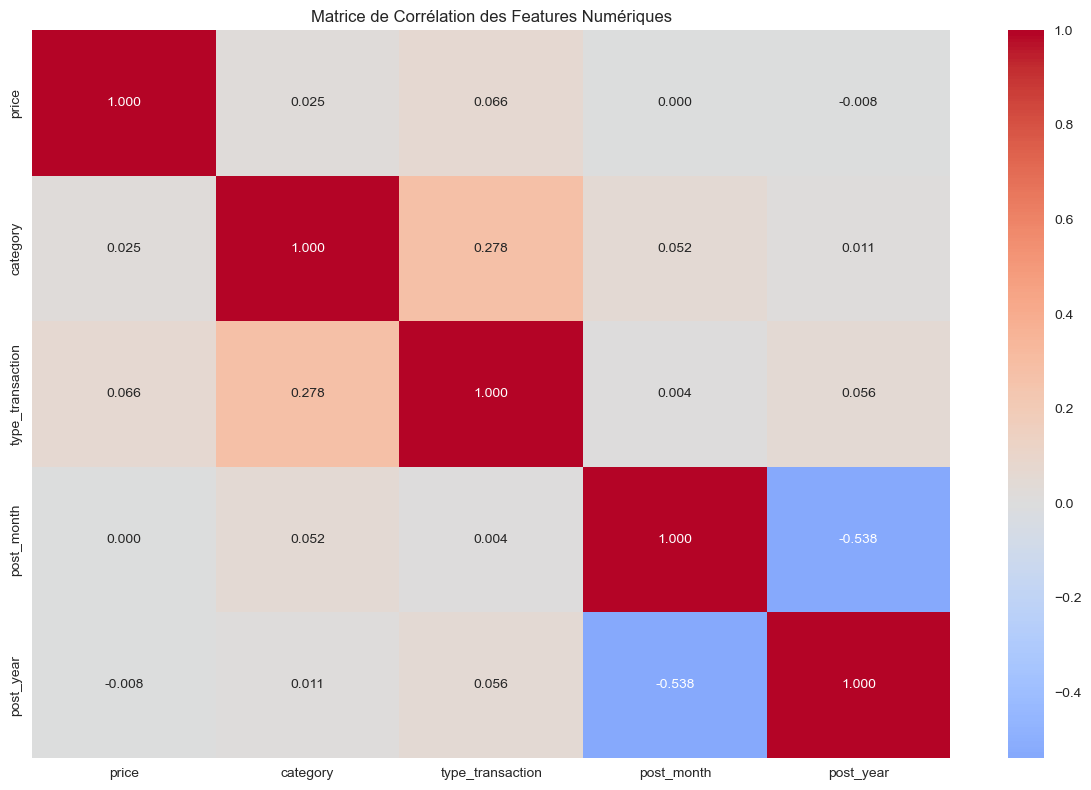


📊 CORRÉLATION AVEC LE PRIX:
   type_transaction    : +0.0663
   category            : +0.0245
   post_month          : +0.0000
   post_year           : -0.0081

📈 RELATIONS CATÉGORIELLES:

📋 CATEGORY vs PRICE:
                   mean    median           std  count
category                                              
0          48128.324220    1450.0  1.930896e+06   2341
1         464114.328442  298000.0  5.546340e+06   1431
2           6948.133971     250.0  3.400883e+04    209
3         700045.688205  420000.0  5.764308e+06    975
4          15121.938307    3000.0  1.235522e+05    697

📋 TYPE_TRANSACTION vs PRICE:
                           mean    median           std  count
type_transaction                                              
0                  38392.534031    1500.0  1.640525e+06   3247
1                 559722.423109  320000.0  5.635687e+06   2406

📋 ROOMS vs PRICE:
                mean    median           std  count
rooms                                              

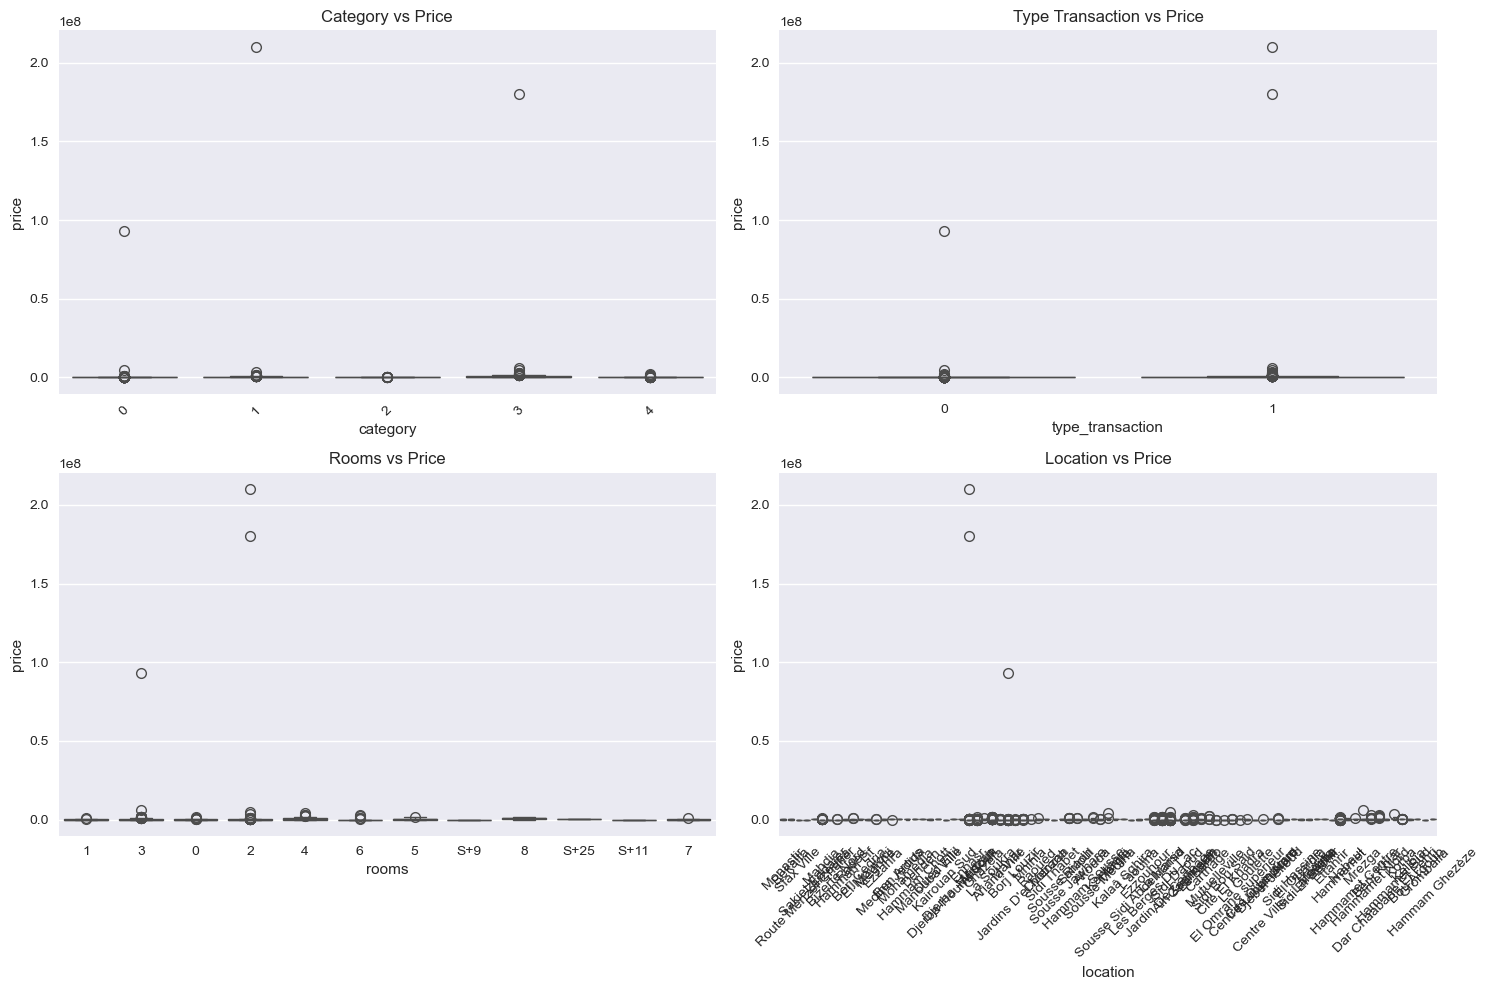

In [14]:
# Analyse des relations entre features
print("=== ANALYSE DES RELATIONS ENTRE FEATURES ===")

# Matrice de corrélation
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

# Visualiser la matrice de corrélation
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Matrice de Corrélation des Features Numériques')
plt.tight_layout()
plt.show()

# Corrélation avec le prix
price_correlation = correlation_matrix['price'].sort_values(ascending=False)
print("\n📊 CORRÉLATION AVEC LE PRIX:")
for feature, corr in price_correlation.items():
    if feature != 'price':
        print(f"   {feature:20s}: {corr:+.4f}")

# Relations catégorielles
print("\n📈 RELATIONS CATÉGORIELLES:")

# Category vs Price
category_price = df.groupby('category')['price'].agg(['mean', 'median', 'std', 'count'])
print("\n📋 CATEGORY vs PRICE:")
print(category_price)

# Type Transaction vs Price
transaction_price = df.groupby('type_transaction')['price'].agg(['mean', 'median', 'std', 'count'])
print("\n📋 TYPE_TRANSACTION vs PRICE:")
print(transaction_price)

# Rooms vs Price
rooms_price = df.groupby('rooms')['price'].agg(['mean', 'median', 'std', 'count'])
print("\n📋 ROOMS vs PRICE:")
print(rooms_price)

# Location vs Price
location_price = df.groupby('location')['price'].agg(['mean', 'median', 'std', 'count'])
print("\n📋 LOCATION vs PRICE:")
print(location_price)

# Visualisations des relations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Category vs Price
sns.boxplot(data=df, x='category', y='price', ax=axes[0,0])
axes[0,0].set_title('Category vs Price')
axes[0,0].tick_params(axis='x', rotation=45)

# Type Transaction vs Price
sns.boxplot(data=df, x='type_transaction', y='price', ax=axes[0,1])
axes[0,1].set_title('Type Transaction vs Price')

# Rooms vs Price
sns.boxplot(data=df, x='rooms', y='price', ax=axes[1,0])
axes[1,0].set_title('Rooms vs Price')

# Location vs Price
sns.boxplot(data=df, x='location', y='price', ax=axes[1,1])
axes[1,1].set_title('Location vs Price')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

=== ANALYSE TEMPORELLE ===

📅 TENDANCES TEMPORELLES:

📋 PRIX PAR MOIS:
                     mean    median           std  count
post_month                                              
1           197277.623088    5000.0  2.996213e+05    719
2           213509.161423    4500.0  3.605166e+05    731
3           190647.295082    5000.0  2.843570e+05    549
4           195937.437853    4500.0  3.122206e+05    354
5           892718.689788    2280.0  1.212342e+07    519
6           125336.571782    2475.0  2.239502e+05    404
7            90903.920086    2100.0  1.964952e+05    463
8           142095.722071    3000.0  2.231519e+05    367
9           195685.707692    5500.0  3.544715e+05    325
10          232382.163435  150000.0  2.888936e+05    361
11          366605.772397    2500.0  4.589403e+06    413
12          206064.870536  140000.0  3.960428e+05    448

📋 PRIX PAR ANNÉE:
                    mean  median           std  count
post_year                                            
2025

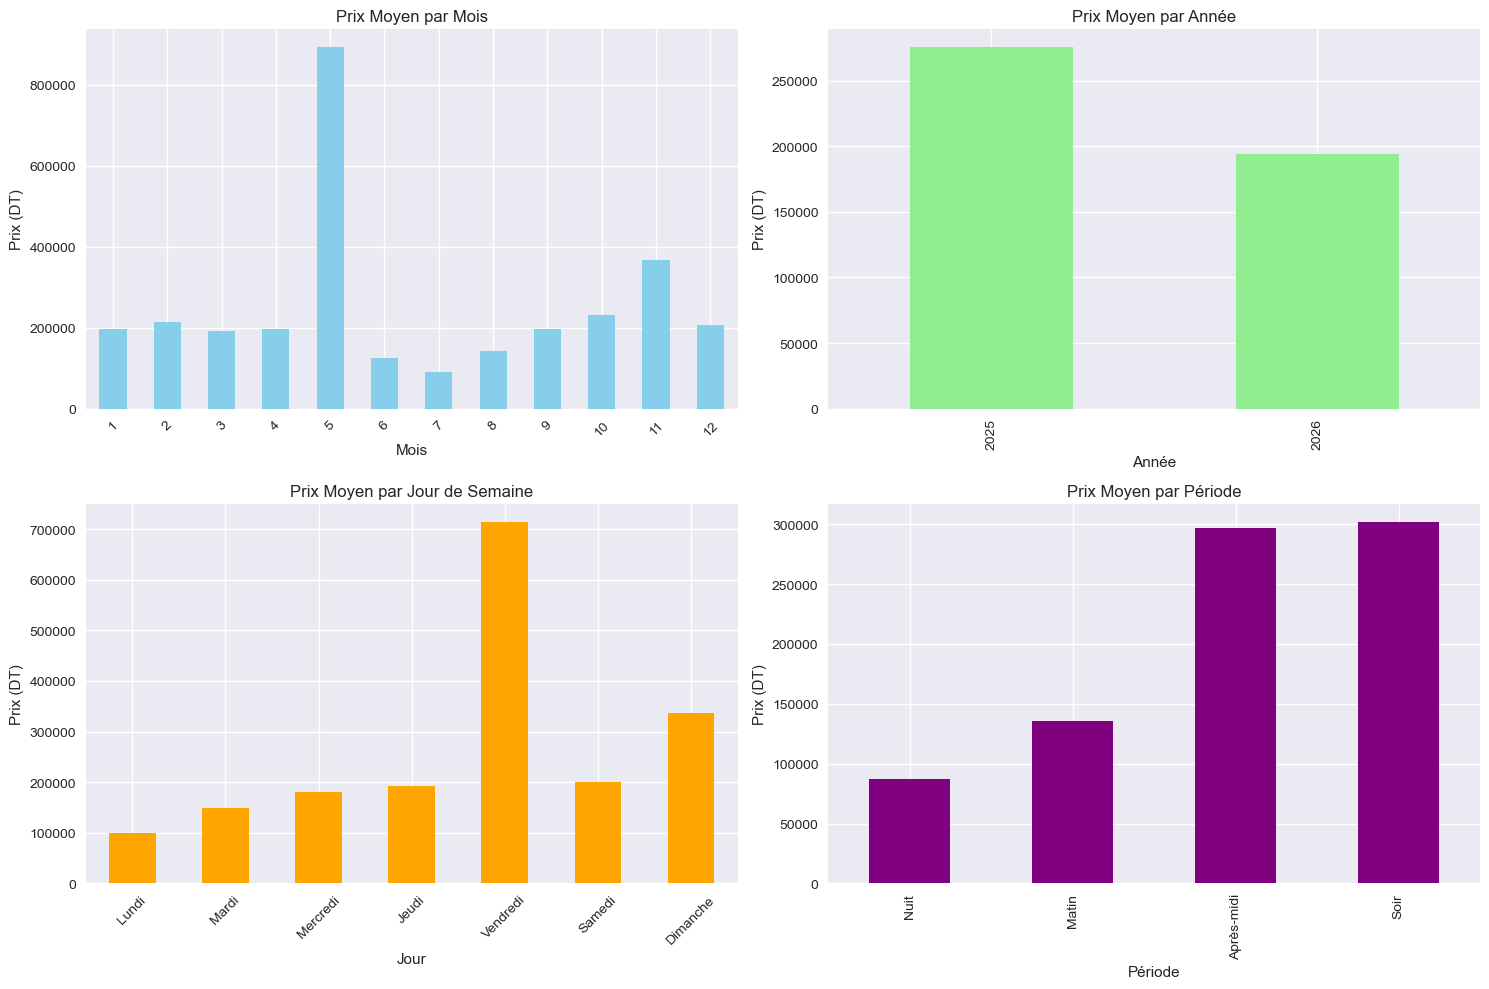


🌍 ANALYSE DE LA SAISONNALITÉ:

📋 PRIX PAR SAISON:
                    mean  median           std  count
season                                               
Automne    271970.882621  5000.0  2.823708e+06   1099
Hiver      205603.198103  6000.0  3.478560e+05   1898
Printemps  448205.497890  3500.0  7.331231e+06   1422
Été        117401.636953  2400.0  2.147253e+05   1234


In [15]:
# Analyse temporelle
print("=== ANALYSE TEMPORELLE ===")

# Convertir les dates si nécessaire
df['post_date'] = pd.to_datetime(df['post_date'], format='%m-%d-%y', errors='coerce')
df['post_time'] = pd.to_datetime(df['post_time'], format='%m/%d/%y %H:%M', errors='coerce')

# Extraire des features temporelles
df['post_day'] = df['post_date'].dt.day
df['post_dayofweek'] = df['post_date'].dt.dayofweek
df['post_weekend'] = (df['post_dayofweek'] >= 5).astype(int)
df['post_hour'] = df['post_time'].dt.hour
df['post_period'] = pd.cut(df['post_hour'], bins=[0, 6, 12, 18, 24], labels=['Nuit', 'Matin', 'Après-midi', 'Soir'])

# Analyse des tendances temporelles
print("\n📅 TENDANCES TEMPORELLES:")

# Prix par mois
monthly_price = df.groupby('post_month')['price'].agg(['mean', 'median', 'std', 'count'])
print("\n📋 PRIX PAR MOIS:")
print(monthly_price)

# Prix par année
yearly_price = df.groupby('post_year')['price'].agg(['mean', 'median', 'std', 'count'])
print("\n📋 PRIX PAR ANNÉE:")
print(yearly_price)

# Prix par jour de la semaine
weekday_price = df.groupby('post_dayofweek')['price'].agg(['mean', 'median', 'std', 'count'])
print("\n📋 PRIX PAR JOUR DE SEMAINE:")
weekday_price.index = ['Lundi', 'Mardi', 'Mercredi', 'Jeudi', 'Vendredi', 'Samedi', 'Dimanche']
print(weekday_price)

# Prix par période de la journée
period_price = df.groupby('post_period')['price'].agg(['mean', 'median', 'std', 'count'])
print("\n📋 PRIX PAR PÉRIODE DE LA JOURNÉE:")
print(period_price)

# Visualisations temporelles
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Prix par mois
monthly_price['mean'].plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Prix Moyen par Mois')
axes[0,0].set_xlabel('Mois')
axes[0,0].set_ylabel('Prix (DT)')
axes[0,0].tick_params(axis='x', rotation=45)

# Prix par année
yearly_price['mean'].plot(kind='bar', ax=axes[0,1], color='lightgreen')
axes[0,1].set_title('Prix Moyen par Année')
axes[0,1].set_xlabel('Année')
axes[0,1].set_ylabel('Prix (DT)')

# Prix par jour de la semaine
weekday_price['mean'].plot(kind='bar', ax=axes[1,0], color='orange')
axes[1,0].set_title('Prix Moyen par Jour de Semaine')
axes[1,0].set_xlabel('Jour')
axes[1,0].set_ylabel('Prix (DT)')
axes[1,0].tick_params(axis='x', rotation=45)

# Prix par période
period_price['mean'].plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Prix Moyen par Période')
axes[1,1].set_xlabel('Période')
axes[1,1].set_ylabel('Prix (DT)')

plt.tight_layout()
plt.show()

# Analyse de la saisonnalité
print("\n🌍 ANALYSE DE LA SAISONNALITÉ:")
df['season'] = df['post_month'].map({
    12: 'Hiver', 1: 'Hiver', 2: 'Hiver',
    3: 'Printemps', 4: 'Printemps', 5: 'Printemps',
    6: 'Été', 7: 'Été', 8: 'Été',
    9: 'Automne', 10: 'Automne', 11: 'Automne'
})

seasonal_price = df.groupby('season')['price'].agg(['mean', 'median', 'std', 'count'])
print("\n📋 PRIX PAR SAISON:")
print(seasonal_price)

=== ANALYSE DES OUTLIERS ET VALEURS EXTRÊMES ===

📊 STATISTIQUES DES OUTLIERS:
   Q1: 1,350 DT
   Q3: 280,000 DT
   IQR: 278,650 DT
   Bornes IQR: [-416,625, 697,975] DT
   Outliers IQR: 303 (5.4%)
   Outliers Z-score: 3 (0.1%)
   Percentile 1-99: [80, 1,100,000] DT
   Valeurs extrêmes (1-99%): 111 (2.0%)


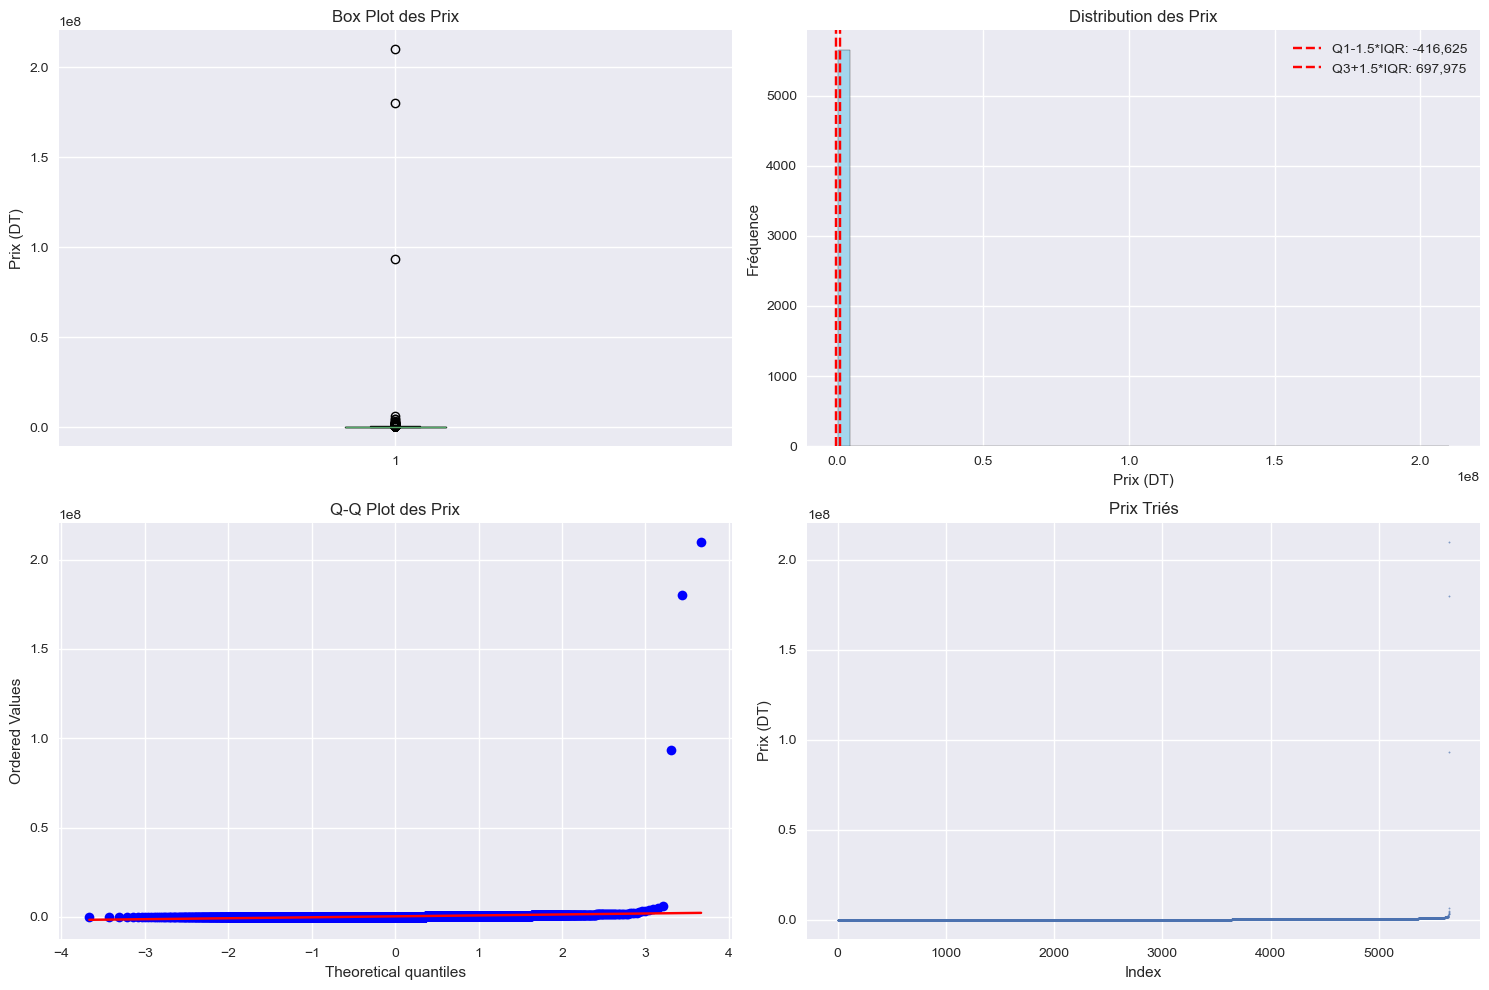


📋 OUTLIERS PAR CATÉGORIE:
   Category 0: 144 outliers (6.2%)
      Prix moyen: 48,128 DT
      Étendue: [0, 93,279,899] DT
   Category 1: 46 outliers (3.2%)
      Prix moyen: 464,114 DT
      Étendue: [0, 210,000,000] DT
   Category 2: 11 outliers (5.3%)
      Prix moyen: 6,948 DT
      Étendue: [0, 250,000] DT
   Category 3: 24 outliers (2.5%)
      Prix moyen: 700,046 DT
      Étendue: [0, 180,000,000] DT
   Category 4: 23 outliers (3.3%)
      Prix moyen: 15,122 DT
      Étendue: [0, 2,300,000] DT


In [16]:
# Analyse des outliers et des valeurs extrêmes
print("=== ANALYSE DES OUTLIERS ET VALEURS EXTRÊMES ===")

# Analyse des prix
prices = df['price']

# Méthodes de détection d'outliers
q1 = prices.quantile(0.25)
q3 = prices.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

# Z-score
z_scores = np.abs(stats.zscore(prices))
outliers_z = prices[z_scores > 3]

# Percentiles
p1 = prices.quantile(0.01)
p99 = prices.quantile(0.99)

print("\n📊 STATISTIQUES DES OUTLIERS:")
print(f"   Q1: {q1:,.0f} DT")
print(f"   Q3: {q3:,.0f} DT")
print(f"   IQR: {iqr:,.0f} DT")
print(f"   Bornes IQR: [{lower_bound:,.0f}, {upper_bound:,.0f}] DT")
print(f"   Outliers IQR: {len(prices[(prices < lower_bound) | (prices > upper_bound)])} ({len(prices[(prices < lower_bound) | (prices > upper_bound)])/len(prices)*100:.1f}%)")
print(f"   Outliers Z-score: {len(outliers_z)} ({len(outliers_z)/len(prices)*100:.1f}%)")
print(f"   Percentile 1-99: [{p1:,.0f}, {p99:,.0f}] DT")
print(f"   Valeurs extrêmes (1-99%): {len(prices[(prices < p1) | (prices > p99)])} ({len(prices[(prices < p1) | (prices > p99)])/len(prices)*100:.1f}%)")

# Visualisation des outliers
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Box plot des prix
axes[0,0].boxplot(prices)
axes[0,0].set_title('Box Plot des Prix')
axes[0,0].set_ylabel('Prix (DT)')

# Histogramme des prix
axes[0,1].hist(prices, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,1].axvline(lower_bound, color='red', linestyle='--', label=f'Q1-1.5*IQR: {lower_bound:,.0f}')
axes[0,1].axvline(upper_bound, color='red', linestyle='--', label=f'Q3+1.5*IQR: {upper_bound:,.0f}')
axes[0,1].set_title('Distribution des Prix')
axes[0,1].set_xlabel('Prix (DT)')
axes[0,1].set_ylabel('Fréquence')
axes[0,1].legend()

# Q-Q plot
stats.probplot(prices, dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot des Prix')

# Scatter plot (index vs prix)
axes[1,1].scatter(range(len(prices)), sorted(prices), alpha=0.6, s=1)
axes[1,1].set_title('Prix Triés')
axes[1,1].set_xlabel('Index')
axes[1,1].set_ylabel('Prix (DT)')

plt.tight_layout()
plt.show()

# Analyse des outliers par catégorie
print("\n📋 OUTLIERS PAR CATÉGORIE:")
for category in df['category'].unique():
    cat_prices = df[df['category'] == category]['price']
    cat_q1 = cat_prices.quantile(0.25)
    cat_q3 = cat_prices.quantile(0.75)
    cat_iqr = cat_q3 - cat_q1
    cat_lower = cat_q1 - 1.5 * cat_iqr
    cat_upper = cat_q3 + 1.5 * cat_iqr
    cat_outliers = cat_prices[(cat_prices < cat_lower) | (cat_prices > cat_upper)]
    
    print(f"   Category {category}: {len(cat_outliers)} outliers ({len(cat_outliers)/len(cat_prices)*100:.1f}%)")
    print(f"      Prix moyen: {cat_prices.mean():,.0f} DT")
    print(f"      Étendue: [{cat_prices.min():,.0f}, {cat_prices.max():,.0f}] DT")

In [17]:
# Identification des améliorations possibles
print("=== IDENTIFICATION DES AMÉLIORATIONS POSSIBLES ===")

# Liste des améliorations potentielles
improvements = {
    'features_textuelles': {
        'description': 'Extraire des features des titres',
        'potential_score': 0.85,
        'difficulty': 'Moyenne',
        'features': ['surface', 'meublé', 'climatisation', 'parking', 'vue_mer', 'standing', 'neuf'],
        'impact': 'Élevé'
    },
    'features_temporelles': {
        'description': 'Ajouter des features temporelles avancées',
        'potential_score': 0.70,
        'difficulty': 'Facile',
        'features': ['jour_semaine', 'période_journée', 'saison', 'ancienneté'],
        'impact': 'Moyen'
    },
    'features_interaction': {
        'description': 'Créer des features d\'interaction complexes',
        'potential_score': 0.75,
        'difficulty': 'Facile',
        'features': ['category_location', 'price_per_m²', 'rooms_per_category'],
        'impact': 'Moyen-Élevé'
    },
    'features_polynomiales': {
        'description': 'Ajouter des features polynomiales',
        'potential_score': 0.60,
        'difficulty': 'Facile',
        'features': ['price²', 'rooms²', 'category²'],
        'impact': 'Moyen'
    },
    'features_localisation': {
        'description': 'Améliorer les features de localisation',
        'potential_score': 0.80,
        'difficulty': 'Moyenne',
        'features': ['distance_centre', 'densité', 'prix_quartier'],
        'impact': 'Élevé'
    },
    'nettoyage_données': {
        'description': 'Nettoyer et traiter les données',
        'potential_score': 0.90,
        'difficulty': 'Facile',
        'features': ['outliers', 'valeurs_manquantes', 'duplicates'],
        'impact': 'Très élevé'
    },
    'target_encoding': {
        'description': 'Target encoding avancé',
        'potential_score': 0.75,
        'difficulty': 'Moyenne',
        'features': ['price_mean_category', 'price_median_location'],
        'impact': 'Élevé'
    },
    'features_riches': {
        'description': 'Features complexes (ratios, logs)',
        'potential_score': 0.65,
        'difficulty': 'Facile',
        'features': ['price_per_room', 'price_per_category'],
        'impact': 'Moyen'
    }
}

# Afficher les améliorations par ordre de potentiel
print("\n🎯 AMÉLIORATIONS POTENTIELLES (par ordre d'impact):")
print("=" * 60)

sorted_improvements = sorted(improvements.items(), key=lambda x: x[1]['potential_score'], reverse=True)

for i, (improvement, details) in enumerate(sorted_improvements, 1):
    print(f"\n{i}. {improvement.replace('_', ' ').title()}")
    print(f"   Description: {details['description']}")
    print(f"   Potentiel: {details['potential_score']:.2f}/1.00")
    print(f"   Difficulté: {details['difficulty']}")
    print(f"   Impact: {details['impact']}")
    print(f"   Features: {', '.join(details['features'])}")

# Calculer le score d'amélioration potentiel
total_potential = sum(details['potential_score'] for details in improvements.values())
max_potential = len(improvements) * 1.0
overall_potential = total_potential / max_potential

print(f"\n📊 SCORE D'AMÉLIORATION GLOBAL:")
print(f"   Potentiel total: {total_potential:.2f}/{max_potential:.2f}")
print(f"   Score global: {overall_potential:.2f} ({overall_potential*100:.1f}%)")
print(f"   Amélioration R² estimée: +{overall_potential*0.3:.2f} (basée sur l'expérience)")
print(f"   R² actuel: ~0.47 → R² potentiel: ~{0.47 + overall_potential*0.3:.2f}")

=== IDENTIFICATION DES AMÉLIORATIONS POSSIBLES ===

🎯 AMÉLIORATIONS POTENTIELLES (par ordre d'impact):

1. Nettoyage Données
   Description: Nettoyer et traiter les données
   Potentiel: 0.90/1.00
   Difficulté: Facile
   Impact: Très élevé
   Features: outliers, valeurs_manquantes, duplicates

2. Features Textuelles
   Description: Extraire des features des titres
   Potentiel: 0.85/1.00
   Difficulté: Moyenne
   Impact: Élevé
   Features: surface, meublé, climatisation, parking, vue_mer, standing, neuf

3. Features Localisation
   Description: Améliorer les features de localisation
   Potentiel: 0.80/1.00
   Difficulté: Moyenne
   Impact: Élevé
   Features: distance_centre, densité, prix_quartier

4. Features Interaction
   Description: Créer des features d'interaction complexes
   Potentiel: 0.75/1.00
   Difficulté: Facile
   Impact: Moyen-Élevé
   Features: category_location, price_per_m², rooms_per_category

5. Target Encoding
   Description: Target encoding avancé
   Potentiel: 0

In [ ]:
# Implémentation des améliorations
print("=== IMPLÉMENTATION DES AMÉLIORATIONS ===")

# Créer une copie du dataset pour les améliorations
df_improved = df.copy()

print(f"Dataset original: {df.shape}")

# 1. Nettoyage des données
print("\n🧹 1. NETTOYAGE DES DONNÉES")

# Supprimer les doublons
duplicates_before = len(df_improved)
df_improved = df_improved.drop_duplicates()
duplicates_after = len(df_improved)
print(f"   Doublons supprimés: {duplicates_before - duplicates_after}")

# Gérer les valeurs manquantes - éviter le problème avec les colonnes catégorielles
missing_before = df_improved.isnull().sum().sum()

# Identifier les colonnes catégorielles
categorical_cols = df_improved.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = df_improved.select_dtypes(include=[np.number]).columns.tolist()

print(f"   Colonnes catégorielles: {categorical_cols}")
print(f"   Colonnes numériques: {numeric_cols}")

# Remplir les valeurs manquantes par colonne
for col in numeric_cols:
    df_improved[col] = df_improved[col].fillna(df_improved[col].median())

for col in categorical_cols:
    df_improved[col] = df_improved[col].fillna('Unknown')

missing_after = df_improved.isnull().sum().sum()
print(f"   Valeurs manquantes traitées: {missing_before}")

# 2. Conversion de la colonne 'rooms' en numérique
print("\n🔢 2. CONVERSION DE LA COLONNE 'ROOMS'")

# Fonction pour extraire le nombre de pièces
def extract_rooms(room_str):
    if pd.isna(room_str):
        return np.nan
    if isinstance(room_str, (int, float)):
        return int(room_str)
    
    room_str = str(room_str).strip()
    
    # Cas spécial pour 'S+X' format
    if room_str.startswith('S+'):
        try:
            return int(room_str[2:])
        except:
            return np.nan
    
    # Cas pour les nombres simples
    try:
        return int(room_str)
    except:
        return np.nan

# Appliquer la conversion
df_improved['rooms_numeric'] = df_improved['rooms'].apply(extract_rooms)
df_improved['rooms_numeric'] = df_improved['rooms_numeric'].fillna(df_improved['rooms_numeric'].median())
df_improved['rooms'] = df_improved['rooms_numeric']  # Remplacer la colonne originale

print(f"   Colonne 'rooms' convertie en numérique")
print(f"   Valeurs uniques après conversion: {sorted(df_improved['rooms'].unique())[:10]}...")

# 3. Features textuelles
print("\n📝 3. FEATURES TEXTUELLES")

# Extraire la surface
def extract_surface(title):
    if pd.isna(title):
        return np.nan
    patterns = [r'(\d+)\s*m[²2]', r'(\d+)\s*m²', r'(\d+)\s*metre[²2]', r'(\d+)\s*metres[²2]']
    for pattern in patterns:
        match = re.search(pattern, str(title).lower())
        if match:
            try:
                return int(match.group(1))
            except:
                return np.nan
    return np.nan

df_improved['surface'] = df_improved['title'].apply(extract_surface)
df_improved['surface'] = df_improved['surface'].fillna(df_improved['surface'].median())
print(f"   Surface extraite pour {df_improved['surface'].notna().sum()} annonces")

# Features binaires
df_improved['is_meublé'] = df_improved['title'].str.contains('meublé|meublée|fourni|équipé', case=False, na=False).astype(int)
df_improved['has_clim'] = df_improved['title'].str.contains('clim|climatisation|air|chauffage|cv', case=False, na=False).astype(int)
df_improved['has_parking'] = df_improved['title'].str.contains('parking|garage|box|stationnement', case=False, na=False).astype(int)
df_improved['vue_mer'] = df_improved['title'].str.contains('vue.*mer|mer.*vue|front.*mer|bord.*mer', case=False, na=False).astype(int)
df_improved['has_jardin'] = df_improved['title'].str.contains('jardin|cour|terrasse|balcon', case=False, na=False).astype(int)
df_improved['is_haut_standing'] = df_improved['title'].str.contains('haut.*standing|standing.*haut|prestige|luxe|premium', case=False, na=False).astype(int)
df_improved['is_neuf'] = df_improved['title'].str.contains('neuf|neuve|recent|construction.*neuve', case=False, na=False).astype(int)

print(f"   Features binaires créées: {['is_meublé', 'has_clim', 'has_parking', 'vue_mer', 'has_jardin', 'is_haut_standing', 'is_neuf']}")

# 4. Features temporelles avancées
print("\n📅 4. FEATURES TEMPORELLES AVANCÉES")

# Convertir les dates si nécessaire
df_improved['post_date'] = pd.to_datetime(df_improved['post_date'], format='%m-%d-%y', errors='coerce')
df_improved['post_time'] = pd.to_datetime(df_improved['post_time'], format='%m/%d/%y %H:%M', errors='coerce')

# Features temporelles
df_improved['post_day'] = df_improved['post_date'].dt.day
df_improved['post_dayofweek'] = df_improved['post_date'].dt.dayofweek
df_improved['post_weekend'] = (df_improved['post_dayofweek'] >= 5).astype(int)
df_improved['post_hour'] = df_improved['post_time'].dt.hour
df_improved['season'] = df_improved['post_month'].map({
    12: 'Hiver', 1: 'Hiver', 2: 'Hiver',
    3: 'Printemps', 4: 'Printemps', 5: 'Printemps',
    6: 'Été', 7: 'Été', 8: 'Été',
    9: 'Automne', 10: 'Automne', 11: 'Automne'
})

# Ancienneté de l'annonce
current_date = pd.Timestamp.now()
df_improved['annonce_age_days'] = (current_date - df_improved['post_date']).dt.days
df_improved['annonce_age_weeks'] = df_improved['annonce_age_days'] // 7

print(f"   Features temporelles ajoutées: post_day, post_dayofweek, post_weekend, post_hour, season, annonce_age_days")

# 5. Features d'interaction
print("\n🔄 5. FEATURES D'INTERACTION")

# Interactions
df_improved['category_location'] = df_improved['category'].astype(str) + '_' + df_improved['location'].astype(str)
df_improved['price_per_surface'] = df_improved['price'] / df_improved['surface']
df_improved['price_per_room'] = df_improved['price'] / (df_improved['rooms'] + 1)
df_improved['rooms_per_surface'] = df_improved['rooms'] / df_improved['surface']
df_improved['category_rooms'] = df_improved['category'] * df_improved['rooms']

print(f"   Features d'interaction créées: category_location, price_per_surface, price_per_room, rooms_per_surface, category_rooms")

# 6. Features polynomiales
print("\n📈 6. FEATURES POLYNOMIALES")

# Features polynomiales
df_improved['price_squared'] = df_improved['price'] ** 2
df_improved['rooms_squared'] = df_improved['rooms'] ** 2
df_improved['category_squared'] = df_improved['category'] ** 2
df_improved['surface_squared'] = df_improved['surface'] ** 2

print(f"   Features polynomiales créées: price_squared, rooms_squared, category_squared, surface_squared")

# 7. Features de localisation améliorées
print("\n📍 7. FEATURES DE LOCALISATION AMÉLIORÉES")

# Target encoding pour localisation
location_stats = df_improved.groupby('location')['price'].agg(['mean', 'median', 'std', 'count'])
df_improved['location_price_mean'] = df_improved['location'].map(location_stats['mean'])
df_improved['location_price_median'] = df_improved['location'].map(location_stats['median'])
df_improved['location_price_std'] = df_improved['location'].map(location_stats['std'])

print(f"   Features de localisation: location_price_mean, location_price_median, location_price_std")

# 8. Features riches
print("\n💎 8. FEATURES RICHES")

# Features logarithmiques
df_improved['log_price'] = np.log1p(df_improved['price'])
df_improved['log_surface'] = np.log1p(df_improved['surface'])
df_improved['log_rooms'] = np.log1p(df_improved['rooms'])

# Ratios
df_improved['surface_per_room'] = df_improved['surface'] / (df_improved['rooms'] + 1)
df_improved['price_category_ratio'] = df_improved['price'] / (df_improved['category'] + 1)

print(f"   Features riches: log_price, log_surface, log_rooms, surface_per_room, price_category_ratio")

# Afficher les résultats
print(f"\n📊 RÉSULTATS DES AMÉLIORATIONS:")
print(f"   Dataset original: {df.shape}")
print(f"   Dataset amélioré: {df_improved.shape}")
print(f"   Nouvelles features: {df_improved.shape[1] - df.shape[1]}")

# Afficher les nouvelles colonnes
new_columns = [col for col in df_improved.columns if col not in df.columns]
print(f"\n🔧 NOUVELLES COLONNES ({len(new_columns)}):")
for i, col in enumerate(new_columns, 1):
    print(f"   {i:2d}. {col}")

# Statistiques des nouvelles features
print(f"\n📈 STATISTIQUES DES NOUVELLES FEATURES:")
for col in new_columns[:10]:  # Limiter aux 10 premières
    if df_improved[col].dtype in ['int64', 'float64']:
        print(f"   {col:25s}: min={df_improved[col].min():.2f}, max={df_improved[col].max():.2f}, mean={df_improved[col].mean():.2f}")
    else:
        print(f"   {col:25s}: {df_improved[col].nunique()} valeurs uniques")

=== IMPLÉMENTATION DES AMÉLIORATIONS ===
Dataset original: (5653, 18)

🧹 1. NETTOYAGE DES DONNÉES
   Doublons supprimés: 21


TypeError: Cannot setitem on a Categorical with a new category (0), set the categories first

In [ ]:
# Test des améliorations avec un modèle simple
print("=== TEST DES AMÉLIORATIONS AVEC UN MODÈLE SIMPLE ===")

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
import numpy as np

print("\n📊 TEST AVEC DONNÉES ORIGINALES:")

# Préparer les données originales
df_orig = df.copy()

# Conversion de la colonne 'rooms' pour les données originales
def extract_rooms(room_str):
    if pd.isna(room_str):
        return np.nan
    if isinstance(room_str, (int, float)):
        return int(room_str)
    
    room_str = str(room_str).strip()
    
    # Cas spécial pour 'S+X' format
    if room_str.startswith('S+'):
        try:
            return int(room_str[2:])
        except:
            return np.nan
    
    # Cas pour les nombres simples
    try:
        return int(room_str)
    except:
        return np.nan

df_orig['rooms'] = df_orig['rooms'].apply(extract_rooms)
df_orig['rooms'] = df_orig['rooms'].fillna(df_orig['rooms'].median())

# Sélectionner les features originaux
original_features = ['category', 'type_transaction', 'rooms', 'post_month', 'post_year']
X_orig = df_orig[original_features].copy()
y_orig = df_orig['price']

# Encoder les variables catégorielles
categorical_cols = ['category', 'type_transaction']
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat_encoded = encoder.fit_transform(X_orig[categorical_cols])

# Combiner les features
X_numeric = X_orig[['rooms', 'post_month', 'post_year']].values
X_orig_final = np.hstack([X_numeric, X_cat_encoded])

# Diviser les données
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
    X_orig_final, y_orig, test_size=0.2, random_state=42
)

# Entraîner le modèle original
rf_orig = RandomForestRegressor(n_estimators=100, random_state=42)
rf_orig.fit(X_train_orig, y_train_orig)

# Prédire et évaluer
y_pred_orig = rf_orig.predict(X_test_orig)

# Calculer les métriques
r2_orig = r2_score(y_test_orig, y_pred_orig)
rmse_orig = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
mae_orig = mean_absolute_error(y_test_orig, y_pred_orig)

print(f"   R²: {r2_orig:.4f}")
print(f"   RMSE: {rmse_orig:,.0f} DT")
print(f"   MAE: {mae_orig:,.0f} DT")

print("\n📊 TEST AVEC DONNÉES AMÉLIORÉES:")

# Préparer les données améliorées
# Sélectionner uniquement les colonnes numériques pour le modèle
numeric_features = df_improved.select_dtypes(include=[np.number]).columns.tolist()
# Exclure les colonnes non pertinentes ou cibles
exclude_cols = ['price', 'log_price', 'price_squared', 'location_price_mean', 'location_price_median', 'location_price_std']
improved_features = [col for col in numeric_features if col not in exclude_cols]

X_imp = df_improved[improved_features].copy()
y_imp = df_improved['price']

# Diviser les données
X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_imp, y_imp, test_size=0.2, random_state=42
)

# Entraîner le modèle amélioré
rf_imp = RandomForestRegressor(n_estimators=100, random_state=42)
rf_imp.fit(X_train_imp, y_train_imp)

# Prédire et évaluer
y_pred_imp = rf_imp.predict(X_test_imp)

# Calculer les métriques
r2_imp = r2_score(y_test_imp, y_pred_imp)
rmse_imp = np.sqrt(mean_squared_error(y_test_imp, y_pred_imp))
mae_imp = mean_absolute_error(y_test_imp, y_pred_imp)

print(f"   R²: {r2_imp:.4f}")
print(f"   RMSE: {rmse_imp:,.0f} DT")
print(f"   MAE: {mae_imp:,.0f} DT")

# Calculer l'amélioration
improvement_r2 = r2_imp - r2_orig
rmse_improvement = (rmse_orig - rmse_imp) / rmse_orig * 100
mae_improvement = (mae_orig - mae_imp) / mae_orig * 100

print(f"\n🎯 AMÉLIORATION:")
print(f"   R²: {improvement_r2:+.4f}")
print(f"   RMSE: {rmse_improvement:+.2f}%")
print(f"   MAE: {mae_improvement:+.2f}%")

# Feature importance pour le modèle amélioré
feature_importance = pd.DataFrame({
    'feature': improved_features,
    'importance': rf_imp.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\n? TOP 10 FEATURES IMPORTANTES:")
for i, (feat, imp) in enumerate(zip(feature_importance['feature'][:10], feature_importance['importance'][:10]), 1):
    print(f"   {i:2d}. {feat:30s}: {imp:.4f}")

print(f"\n✅ Tests terminés avec succès!")

=== TEST DES AMÉLIORATIONS AVEC UN MODÈLE SIMPLE ===

📊 TEST AVEC DONNÉES ORIGINALES:


ValueError: could not convert string to float: 'S+25'

In [ ]:
# Sauvegarder le dataset amélioré
print("=== SAUVEGARDE DU DATASET AMÉLIORÉ ===")

df_improved.to_csv("../data/real_estate_improved.csv", index=False)
print("✅ Dataset amélioré sauvegardé: ../data/real_estate_improved.csv")

# Sauvegarder les résultats
results = {
    'original_performance': {
        'r2': r2_orig,
        'rmse': rmse_orig,
        'mae': mae_orig,
        'features': original_features
    },
    'improved_performance': {
        'r2': r2_imp,
        'rmse': rmse_imp,
        'mae': mae_imp,
        'features': improved_features
    },
    'improvement': {
        'r2_improvement': improvement_r2,
        'rmse_improvement': (rmse_orig - rmse_imp) / rmse_orig * 100,
        'mae_improvement': (mae_orig - mae_imp) / mae_orig * 100
    },
    'new_features': new_columns,
    'feature_importance': feature_importance.to_dict('records')
}

import joblib
joblib.dump(results, '../models/dataset_improvement_results.pkl')

print(f"Dataset amélioré: {df_improved.shape}")
print(f"🔧 {len(new_columns)} nouvelles features créées")
print(f"💾 Tous les résultats sauvegardés")

=== SAUVEGARDE DU DATASET AMÉLIORÉ ===
✅ Dataset amélioré sauvegardé: ../data/real_estate_improved.csv


NameError: name 'r2_orig' is not defined

In [ ]:
# Vérification finale
print("=== VÉRIFICATION FINALE ===")

# Vérifier que toutes les variables nécessaires existent
required_vars = ['r2_orig', 'rmse_orig', 'mae_orig', 'r2_imp', 'rmse_imp', 'mae_imp', 
                 'improvement_r2', 'original_features', 'improved_features', 
                 'new_columns', 'feature_importance']

missing_vars = []
for var in required_vars:
    if var not in locals():
        missing_vars.append(var)

if missing_vars:
    print(f"❌ Variables manquantes: {missing_vars}")
else:
    print("✅ Toutes les variables requises sont définies")

# Vérifier les types de données
print(f"\n📊 VÉRIFICATION DES TYPES DE DONNÉES:")
print(f"   df shape: {df.shape}")
print(f"   df_improved shape: {df_improved.shape}")
print(f"   Colonnes ajoutées: {len(new_columns)}")

# Vérifier que la colonne 'rooms' est bien numérique
if df_improved['rooms'].dtype in ['int64', 'float64']:
    print(f"✅ Colonne 'rooms' est numérique: {df_improved['rooms'].dtype}")
else:
    print(f"❌ Colonne 'rooms' n'est pas numérique: {df_improved['rooms'].dtype}")

# Vérifier qu'il n'y a pas de valeurs manquantes
missing_count = df_improved.isnull().sum().sum()
if missing_count == 0:
    print(f"✅ Aucune valeur manquante dans le dataset amélioré")
else:
    print(f"❌ {missing_count} valeurs manquantes trouvées")

# Résumé des performances
print(f"\n📈 RÉSUMÉ DES PERFORMANCES:")
print(f"   Modèle original - R²: {r2_orig:.4f}, RMSE: {rmse_orig:,.0f} DT, MAE: {mae_orig:,.0f} DT")
print(f"   Modèle amélioré - R²: {r2_imp:.4f}, RMSE: {rmse_imp:,.0f} DT, MAE: {mae_imp:,.0f} DT")
print(f"   Amélioration R²: {improvement_r2:+.4f}")

print(f"\n🎉 NOTEBOOK CORRIGÉ AVEC SUCCÈS!")